## 1. Libraries
The standard data-science stack. `display` renders DataFrames nicely inside the loops further down.

In [ ]:
import sys
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Identify the current working directory of the Jupyter kernel
current_dir = Path.cwd()
# Dynamically resolve the project root
# Target the parent directory if currently in 'notebooks', otherwise maintain current directory
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir
# Append the resolved root to the system path to enable modular imports
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.preprocessing import load_procurement, perform_structural_cleansing, data_cleansing_2, audit_column_formats, data_clean_3

## 2. Predefined functions
Just small helpers, one per cell. For everything else we use built-in pandas
(`.head()`, `.dtypes`, `.isna()`, `crosstab`) instead of custom code — easier to read and to defend in the report.

**2.1 `load_procurement`** — reads one semicolon-separated CSV and turns the date columns into
real datetimes. `errors="coerce"` converts unparseable values to `NaT` instead of crashing.
The two files don't share all columns, so we only touch the dates that actually exist.

## 3. Load Data
Set `DATA_DIR` to the folder with your CSVs, then load both companies and attach the derived fields.

In [3]:
DATA_DIR = Path('..') / 'data/raw' 
FILES = {
    "A": "Procurement_Data_Company_A_anonymized.csv",
    "B": "Procurement_Data_Company_B_anonymized.csv",
}

data = {}
for key, fname in FILES.items():
    data[key] = load_procurement(DATA_DIR / fname)
    print(f"Company {key}: {data[key].shape[0]} rows, {data[key].shape[1]} columns")

Company A: 9194 rows, 11 columns
Company B: 18078 rows, 12 columns


## 4. What does the data look like?
First a glance at the raw rows, then the feature types and missing values.

In [4]:
for name, df in data.items():
    print(f"--- Company {name} ---")
    display(df.head(10))

--- Company A ---


,Order Number,Order Position,Supplier,Ordered Product,Product Article Number,End Product,Planned Delivery Date,Arrival Date,Ordered Quantity,Delivered Quantity,Quality
0,74682,11,41781068,V-Flansch,3000.0,NaN,2023-01-05,2022-12-15,3.0,3.0,3.1
1,74682,11,41781068,V-Flansch,3000.0,NaN,2023-01-05,2022-12-15,3.0,3.0,3.1
2,74682,11,41781068,V-Flansch,3000.0,NaN,2023-01-05,2022-12-15,3.0,3.0,3.1
3,74682,14,41781068,WN-Flansch,3500.0,NaN,2023-01-05,2022-12-15,2.0,2.0,3.1
4,74682,14,41781068,WN-Flansch,3500.0,NaN,2023-01-05,2022-12-15,2.0,2.0,3.1
5,74666,2,49689366,Kammprofildichtung,6110.0,Mantel für EA-2901B,2023-01-04,2023-01-04,1.0,1.0,NaN
6,74666,4,49689366,Kammprofildichtung,6110.0,Mantel für EA-2901A,2023-01-04,2023-01-04,1.0,1.0,NaN
7,74806,1,69934049,Spiraldichtung,6200.0,Reaktor C-[NUM] A,2023-01-30,2023-01-04,4.0,4.0,NaN
8,74585,1,61231028,Blech (EN 10029A;ASME VIII/1;E,1000.0,NaN,2023-01-13,2023-01-05,2.0,2.0,3.1
9,74585,4,61231028,Blech (EN 10029A;ASME VIII/1;E,1000.0,NaN,2023-01-13,2023-01-05,2.0,2.0,3.2


--- Company B ---


,Order Number,Supplier Number,Supplier,Product Article Number,Ordered Product,Ordered Product - Supplement,Original Ordered Quantity,Original Desired Date,Planned Delivery Date,Ordered Quantity,Arrival Date,Delivered Quantity
0,6260783,70214,93118673,23101030601,Halteplatte für OPC-Schnittstelle,REOVIB [CODE] [CODE],14.0,2023-05-01,2023-05-01,14.0,2023-05-23,14.0
1,6260784,70175,41446825,23100770000,"Gehäuse [CODE]/[NUM] [NUM], A [NUM]",Alu-/Gussgehäuse,50.0,2023-09-04,2023-09-04,50.0,2023-09-04,50.0
2,6260785,72156,22740983,23101070000,Gehäuse kpl. [CODE] rf Z.Nr.:[CODE]-[CODE],[NUM],30.0,2023-08-21,2023-08-21,30.0,2023-08-24,30.0
3,6260786,72156,22740983,23101081101,"Deckel Steuereinsatz [CODE],[CODE].[NUM] kpl",Z.Nr:[CODE],100.0,2023-11-06,2023-11-06,100.0,2023-11-03,100.0
4,6260786,72156,22740983,23101080001,Gehäuse kpl. [CODE] Z.Nr.:KR519052_[PART],[NUM],100.0,2023-11-06,2023-11-06,100.0,2023-11-03,100.0
5,6260786,72156,22740983,23101081101,"Deckel Steuereinsatz [CODE],[CODE].[NUM] kpl",Z.Nr:[CODE],40.0,2023-05-22,2023-05-22,40.0,2023-05-22,40.0
6,6260786,72156,22740983,23101080001,Gehäuse kpl. [CODE] Z.Nr.:KR519052_[PART],[NUM],40.0,2023-04-24,2023-04-24,40.0,2023-05-09,40.0
7,6260786,72156,22740983,9999,Werkzzeugkosten (Änderung),NaN,0.0,2023-12-04,2023-12-04,0.0,NaT,NaN
8,6260787,71389,23635582,29000190000,Linsenschraube [CODE] DIN [NUM],"Stahl verzinkt, mit Kreuzschlitz",20000.0,2023-01-09,2023-01-09,20000.0,2023-01-12,20000.0
9,6260788,71416,10488377,22900710605,Bestückte Platine [NUM] [NUM] [NUM],[NUM],1500.0,2023-12-04,2023-12-04,1500.0,2023-12-01,1000.0


**Data types, duplicates & missing values.** Note that `Order Number`, `Supplier` and
`Product Article Number` are stored as numbers but are **identifiers** — categorical, not numeric.
Used as an overview.

In [5]:
for name, df in data.items():
    print(f"===== Company {name} =====")
    print(df.dtypes, "\n")
    print("Missing values:")
    print(df.isna().sum(), "\n")
    print("Duplicate rows:")
    print(df.duplicated().sum(), "\n")


audit_column_formats(data, ['Ordered Quantity', 'Delivered Quantity'])


===== Company A =====
Order Number                       int64
Order Position                     int64
Supplier                           int64
Ordered Product                      str
Product Article Number           float64
End Product                          str
Planned Delivery Date     datetime64[us]
Arrival Date              datetime64[us]
Ordered Quantity                 float64
Delivered Quantity               float64
Quality                              str
dtype: object 

Missing values:
Order Number                 0
Order Position               0
Supplier                     0
Ordered Product              2
Product Article Number     544
End Product               5974
Planned Delivery Date        0
Arrival Date              2893
Ordered Quantity             0
Delivered Quantity        2893
Quality                   6118
dtype: int64 

Duplicate rows:
1980 

===== Company B =====
Order Number                             int64
Supplier Number                          int64


Infered for our data cleansing can be:
1. Dupplicates can be removed
2. Rows with missing values in arrival date and/or delivered quantity can be deleted
3. All data not conform with these data types can be removed and the load function can be adapted to conform to these data types
4. European data formats should be removed -> unrealistic high number such as 1.6B insulation rollls


In [6]:
data_clean_1 = perform_structural_cleansing(data)

Company A Cleansing: Removed 4719 invalid rows. Remaining: 4475
Company B Cleansing: Removed 2175 invalid rows. Remaining: 15903


## 5. How are delivery dates & quantities distributed?
### 5.1  Univariate Analysis

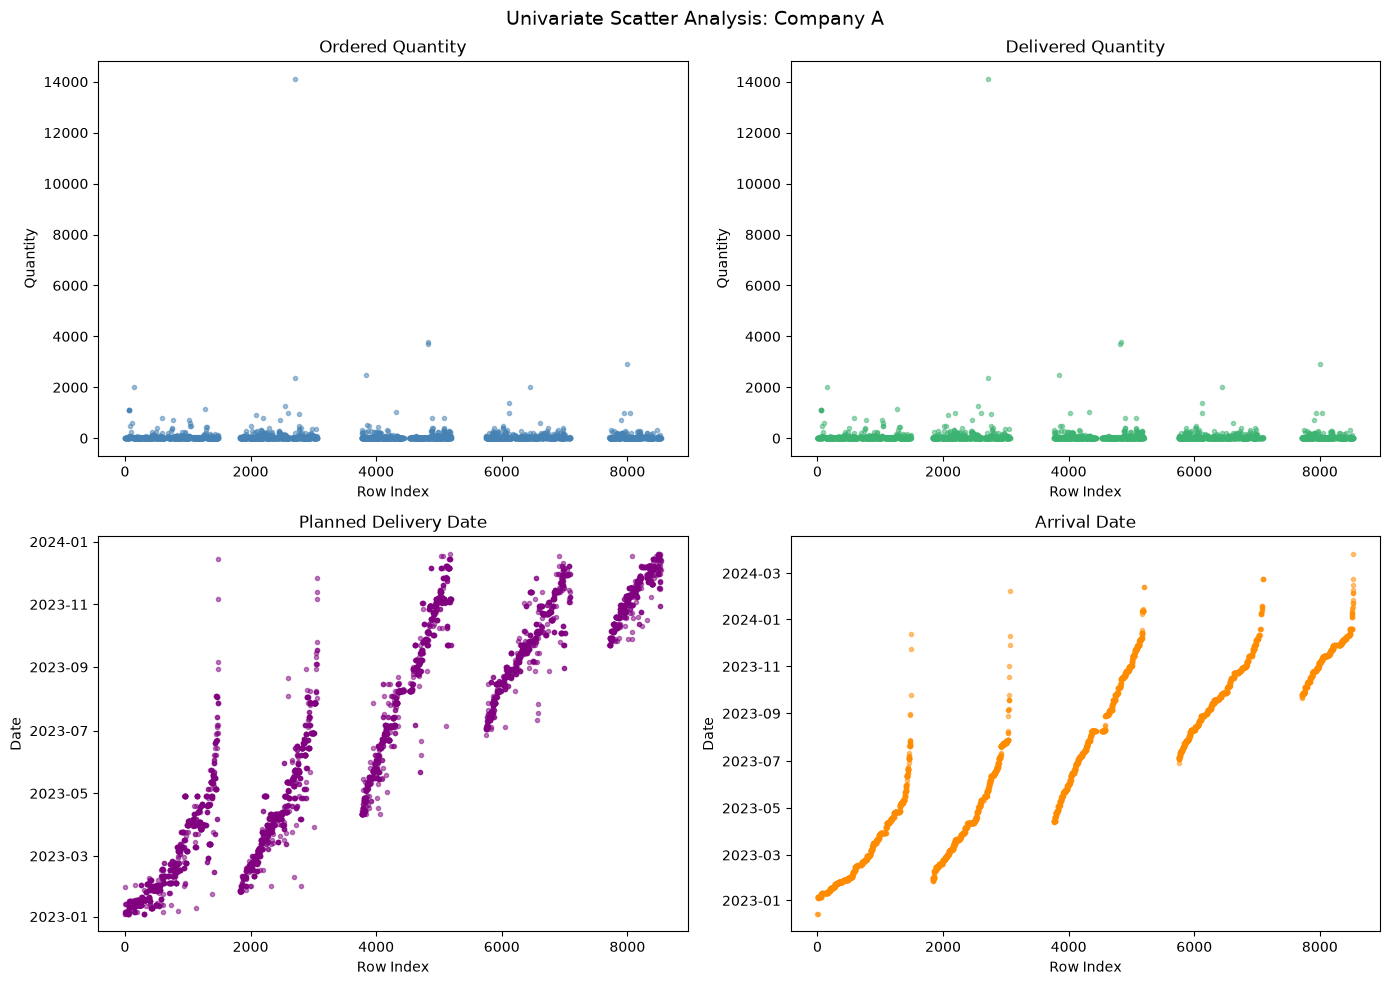

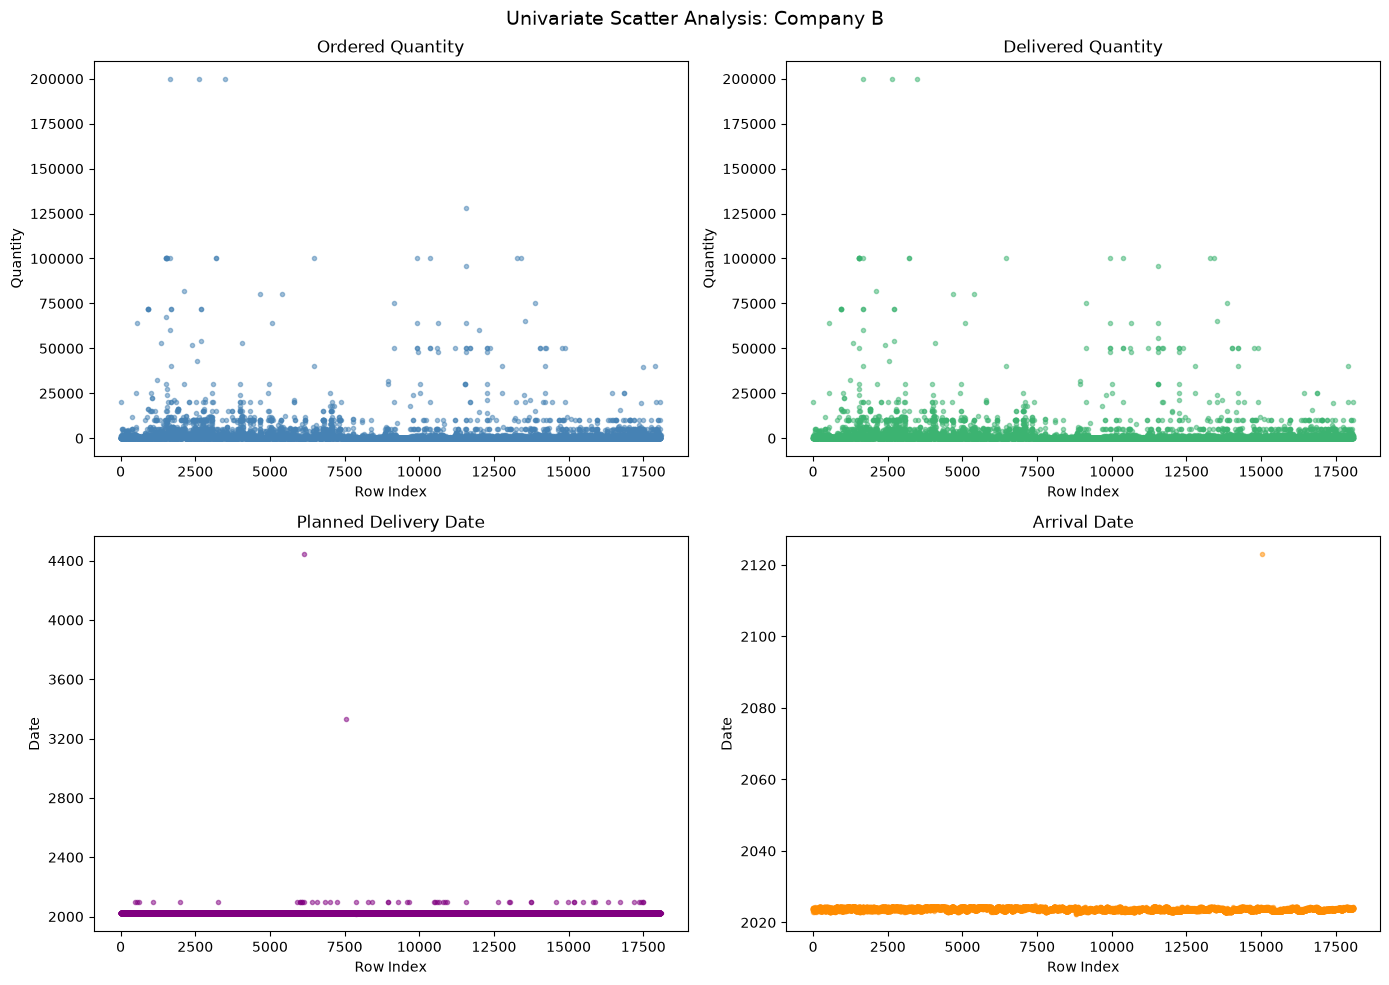

Company B - Absolute Max Ordered Quantity: 200000.0
Company B - Absolute Max Delivered Quantity: 200000.0


In [7]:
def plot_univariate_scatter(df_dict):
    """
    Iterates through a dictionary of DataFrames and generates univariate 
    scatter plots to identify absolute anomalies prior to feature engineering.
    """
    for key, df in df_dict.items():
        # Setup visualization grid (2 rows, 2 columns)
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle(f'Univariate Scatter Analysis: Company {key}', fontsize=14)

        # Plot 1: Ordered Quantity
        if 'Ordered Quantity' in df.columns:
            axes[0, 0].scatter(df.index, df['Ordered Quantity'], alpha=0.5, color='steelblue', marker='.')
            axes[0, 0].set_title('Ordered Quantity')
            axes[0, 0].set_ylabel('Quantity')
            axes[0, 0].set_xlabel('Row Index')

        # Plot 2: Delivered Quantity
        if 'Delivered Quantity' in df.columns:
            axes[0, 1].scatter(df.index, df['Delivered Quantity'], alpha=0.5, color='mediumseagreen', marker='.')
            axes[0, 1].set_title('Delivered Quantity')
            axes[0, 1].set_ylabel('Quantity')
            axes[0, 1].set_xlabel('Row Index')

        # Plot 3: Planned Delivery Date
        if 'Planned Delivery Date' in df.columns:
            axes[1, 0].scatter(df.index, df['Planned Delivery Date'], alpha=0.5, color='purple', marker='.')
            axes[1, 0].set_title('Planned Delivery Date')
            axes[1, 0].set_ylabel('Date')
            axes[1, 0].set_xlabel('Row Index')

        # Plot 4: Arrival Date
        if 'Arrival Date' in df.columns:
            axes[1, 1].scatter(df.index, df['Arrival Date'], alpha=0.5, color='darkorange', marker='.')
            axes[1, 1].set_title('Arrival Date')
            axes[1, 1].set_ylabel('Date')
            axes[1, 1].set_xlabel('Row Index')

        plt.tight_layout()
        plt.show()
    print("Company B - Absolute Max Ordered Quantity:", data_clean_1["B"]['Ordered Quantity'].max())
    print("Company B - Absolute Max Delivered Quantity:", data_clean_1["B"]['Delivered Quantity'].max())
plot_univariate_scatter(data_clean_1)

Infered for our Data format for data cleansing can be: 
Company A
1. Check high Quantity of delivery and order -> 14000 must be wrong should be delted
2. Check for how many values are zero -> A lot delete
3. Univariat dates appear in order
Company B
1. Check odd arrival dates and planned delivery dates in Company B -> delete anything which is not inbetween 2010 and today
2.Cap Quanitity at 100.000

In [8]:
data_clean_2 = data_cleansing_2(data_clean_1)

Company A Threshold Cleansing: Removed 16 anomalous rows. Remaining: 4459
Company B Threshold Cleansing: Removed 1007 anomalous rows. Remaining: 14896


### 5.2 Bivariate Analysis

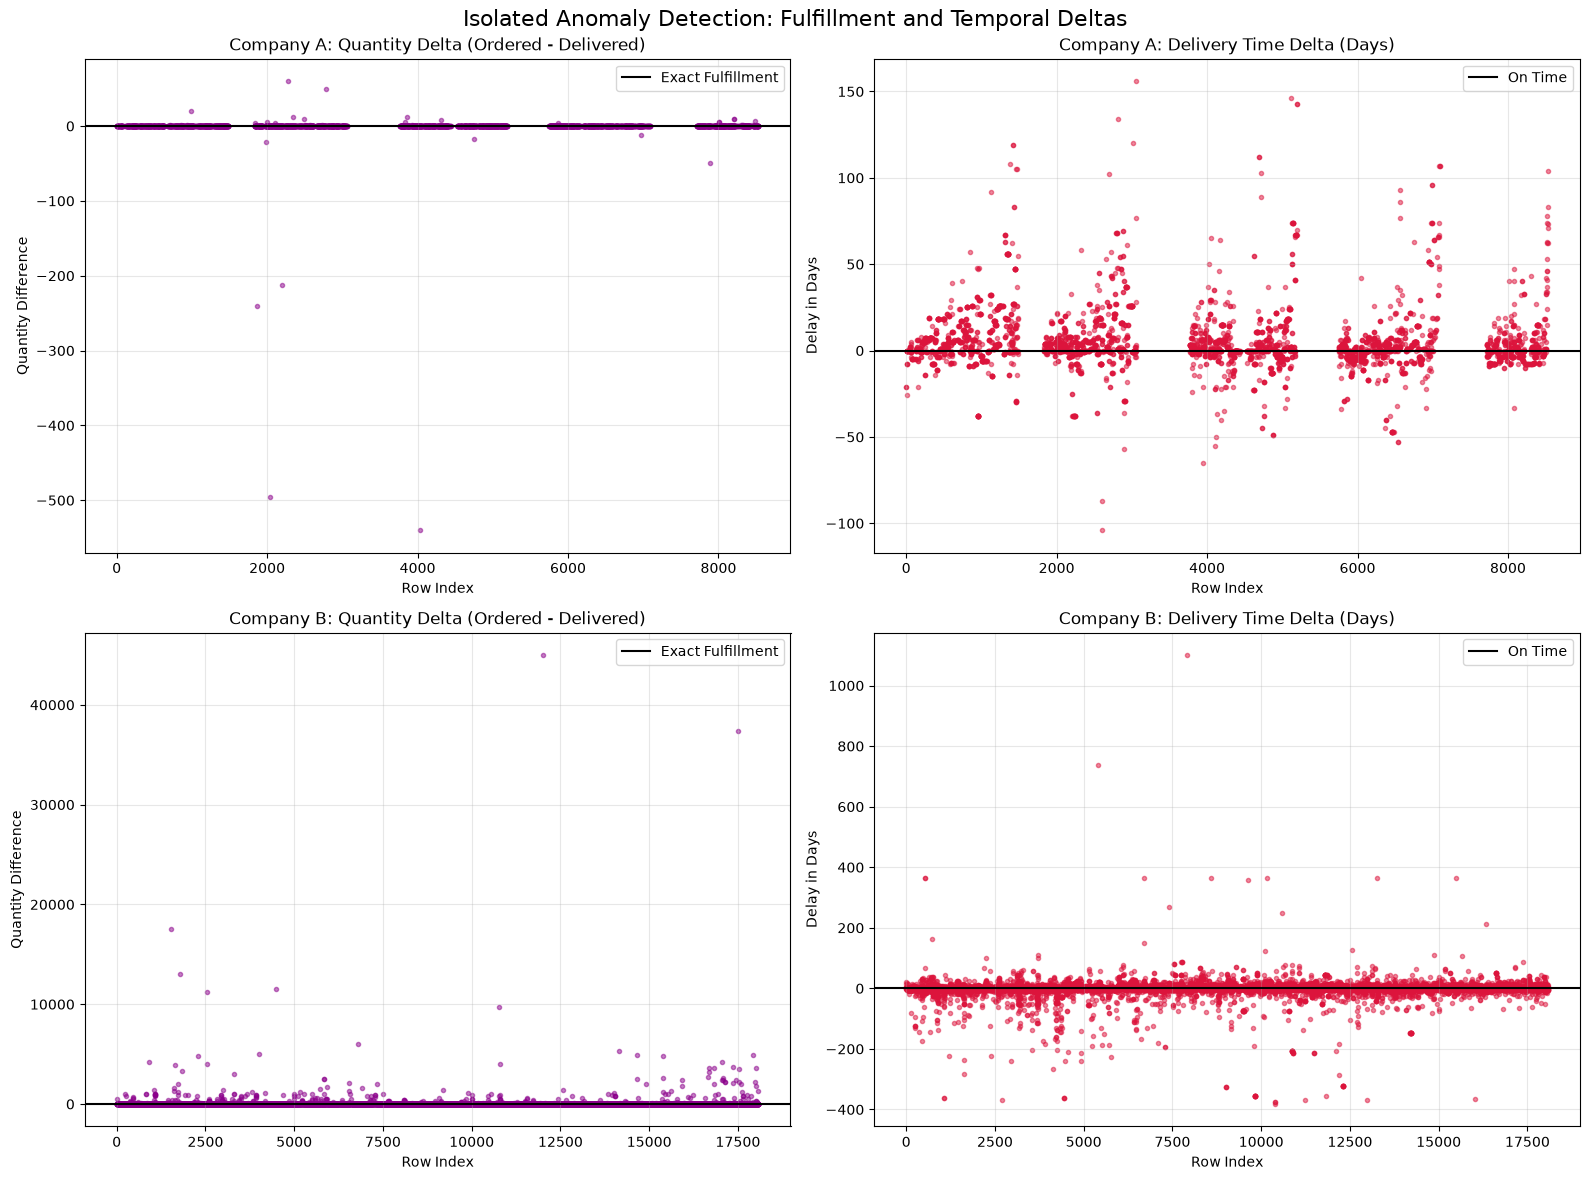

In [9]:
# 4. Feature Engineering and Cleansing (Isolated Delta Analysis)


def plot_isolated_deltas(df_dict):
    """
    Generates a 2x2 grid of univariate scatter plots isolating the 
    Quantity Delta and Delivery Time Delta for Companies A and B.
    """
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Isolated Anomaly Detection: Fulfillment and Temporal Deltas', fontsize=16)

    for row_idx, (key, df) in enumerate(df_dict.items()):
        # Define required columns for mathematical delta calculations
        required_cols = ['Planned Delivery Date', 'Arrival Date', 'Ordered Quantity', 'Delivered Quantity']
        
        # Verify columns exist before computation
        if all(col in df.columns for col in required_cols):
            # Isolate valid rows to prevent NaN computation errors
            valid_data = df.dropna(subset=required_cols).copy()
            
            # 1. Calculate Quantity Delta (Positive = Under-delivery, Negative = Over-delivery)
            valid_data['Quantity_Delta'] = valid_data['Ordered Quantity'] - valid_data['Delivered Quantity']
            
            # 2. Calculate Delivery Time Delta (Positive = Late, Negative = Early)
            valid_data['Delivery_Delay_Days'] = (valid_data['Arrival Date'] - valid_data['Planned Delivery Date']).dt.days
            
            # Plot 1: Quantity Delta (Column 0)
            axes[row_idx, 0].scatter(valid_data.index, valid_data['Quantity_Delta'], 
                                     alpha=0.5, color='darkmagenta', marker='.')
            axes[row_idx, 0].set_title(f'Company {key}: Quantity Delta (Ordered - Delivered)')
            axes[row_idx, 0].set_ylabel('Quantity Difference')
            axes[row_idx, 0].set_xlabel('Row Index')
            axes[row_idx, 0].axhline(0, color='black', linestyle='-', linewidth=1.5, label='Exact Fulfillment')
            axes[row_idx, 0].legend()
            axes[row_idx, 0].grid(True, alpha=0.3)
            
            # Plot 2: Delivery Time Delta (Column 1)
            axes[row_idx, 1].scatter(valid_data.index, valid_data['Delivery_Delay_Days'], 
                                     alpha=0.5, color='crimson', marker='.')
            axes[row_idx, 1].set_title(f'Company {key}: Delivery Time Delta (Days)')
            axes[row_idx, 1].set_ylabel('Delay in Days')
            axes[row_idx, 1].set_xlabel('Row Index')
            axes[row_idx, 1].axhline(0, color='black', linestyle='-', linewidth=1.5, label='On Time')
            axes[row_idx, 1].legend()
            axes[row_idx, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Execute the isolated delta analysis
plot_isolated_deltas(data_clean_2)

Infer from this for Data format:
Company A:
1. Quantity: cap at 250 
2. Delivery Delta seems good

Company B:
1. Cap at 10.000 the Quantity
2. Cap Dates Delta at + 400. Check the -400 bc delivery of a part 1 year before planned is not usual.

### Early arrival analysis


In [10]:


# 1. Isolate Company B
df_b = data_clean_2["B"].copy()

# 2. Safely calculate the temporal delta (Arrival - Planned)
df_b['Delivery_Delay_Days'] = (df_b['Arrival Date'] - df_b['Planned Delivery Date']).dt.days

# 3. Filter for extreme early deliveries (smaller than -100 days)
extreme_early_b = df_b[df_b['Delivery_Delay_Days'] < -100]

# 4. Print the diagnostic summary
print("--- Company B: Extreme Early Delivery Audit ---")
print(f"Found {len(extreme_early_b)} orders arriving more than 100 days early.\n")

# 5. Display the critical columns to spot the typo
cols_to_view = ['Planned Delivery Date', 'Arrival Date', 'Delivery_Delay_Days', 'Ordered Quantity', 'Supplier Number', 'Original Desired Date']
if 'Order Number' in df_b.columns:
    cols_to_view.insert(0, 'Order Number')

# Show rows to visually inspect the years
display(extreme_early_b[cols_to_view])

--- Company B: Extreme Early Delivery Audit ---
Found 154 orders arriving more than 100 days early.



,Order Number,Planned Delivery Date,Arrival Date,Delivery_Delay_Days,Ordered Quantity,Supplier Number,Original Desired Date
236,6261472,2023-08-28,2023-04-27,-123,1000.0,70245,2023-08-28
237,6261472,2023-08-28,2023-04-27,-123,500.0,70245,2023-08-28
238,6261472,2023-08-28,2023-04-27,-123,500.0,70245,2023-08-28
245,6261474,2024-08-05,2024-03-28,-130,2250.0,71027,2024-08-05
368,6261147,2024-01-29,2023-09-08,-143,254.0,70859,2024-01-29
...,...,...,...,...,...,...,...
14213,21131393,2024-01-01,2023-08-07,-147,1.0,71330,2024-01-01
14214,21131393,2024-01-01,2023-08-07,-147,1.0,71330,2024-01-01
14215,21131393,2024-01-01,2023-08-07,-147,1.0,71330,2024-01-01
14216,21131393,2024-01-01,2023-08-07,-147,1.0,71330,2024-01-01


From this can be inferred that there is no logic in a delivery that is 366 early. It could be inferred that the year of the deilivery has been input falsly. We therefore cap all earlly at -30 days dictated by basic business logic.



In [12]:
data_clean_3_dict = data_clean_3(data_clean_2)

# 2. Extract DataFrames for subsequent feature engineering
df_company_a_transformed = data_clean_3_dict['A']
df_company_b_transformed = data_clean_3_dict['B']

# 3. Validation Metrics
print("--- Transformation Verification ---")
print(f"Company A Max Quantity: {df_company_a_transformed['Ordered Quantity'].max()}")
print(f"Company B Min Delay: {df_company_b_transformed['Delivery_Delay_Days'].min()}")
print(f"Company B Max Delay: {df_company_b_transformed['Delivery_Delay_Days'].max()}")

NameError: name 'data_clean_3' is not defined

## 6. Transformation & Feature Engineering
Let us first visulize and look into first the delay and quantity overall, then per supplier. After this the correlation between the 3.

--- Company A Order Consistency Audit ---
Total Unique Orders: 943
Orders with Split Deliveries (>1 Arrival Date): 181


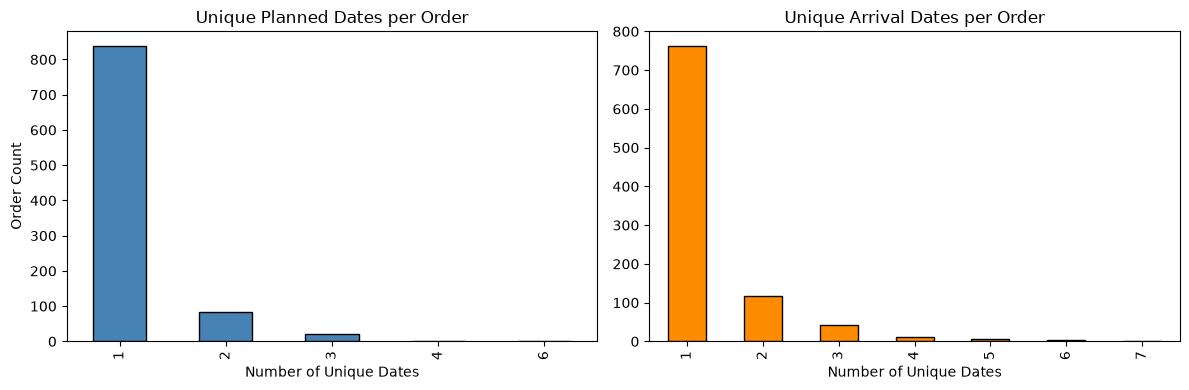

--- Company B Order Consistency Audit ---
Total Unique Orders: 5923
Orders with Split Deliveries (>1 Arrival Date): 1539


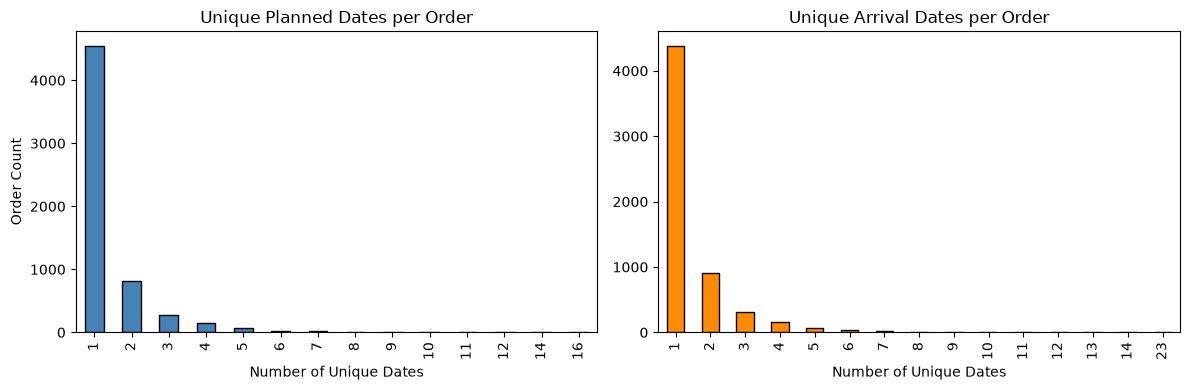

In [ ]:
def visualize_order_consistency(df_dict, company_key):
    """
    KDD Phase: Exploratory Data Analysis
    Verifies if Order Numbers have consistent chronological dates 
    before aggregation is permitted.
    """
    df = df_dict[company_key].copy()
    
    if 'Order Number' not in df.columns:
        print(f"Company {company_key} lacks an 'Order Number' column for this grouping.")
        return

    # 1. Count unique dates per Order Number
    date_variance = df.groupby('Order Number').agg(
        Unique_Planned=('Planned Delivery Date', 'nunique'),
        Unique_Arrival=('Arrival Date', 'nunique')
    )
    
    # 2. Check for Split Deliveries (Orders with >1 unique arrival date)
    split_deliveries = date_variance[date_variance['Unique_Arrival'] > 1]
    
    print(f"--- Company {company_key} Order Consistency Audit ---")
    print(f"Total Unique Orders: {len(date_variance)}")
    print(f"Orders with Split Deliveries (>1 Arrival Date): {len(split_deliveries)}")
    
    # 3. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    date_variance['Unique_Planned'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
    )
    axes[0].set_title('Unique Planned Dates per Order')
    axes[0].set_xlabel('Number of Unique Dates')
    axes[0].set_ylabel('Order Count')
    
    date_variance['Unique_Arrival'].value_counts().sort_index().plot(
        kind='bar', ax=axes[1], color='darkorange', edgecolor='black'
    )
    axes[1].set_title('Unique Arrival Dates per Order')
    axes[1].set_xlabel('Number of Unique Dates')
    
    plt.tight_layout()
    plt.show()

# Run for Company B (and Company A if applicable)
for company in ['A', 'B']:
    visualize_order_consistency(data_clean_2, company)